<a href="https://colab.research.google.com/github/MMujtabaX/Bank-Marketing-ML-Pipeline/blob/main/E2EMLPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pipeline

1.   Download Dataset
2.   Load Dataset
3.   Exploratory Data Analysis (EDA)
4.   Data Cleaning + Train-Test Splitting
5.   Encoding & Scaling
6.   Feature selection
7.   Dimensionality Reduction (PCA)
8.   Handling Class Imbalance (SMOTE)
9.   Model Building & Comparison
10.  Evaluation



**STEP 0 - Install required libraries**

In [1]:
!pip install imbalanced-learn

**STEP 1 — Download Dataset from UCI**

We need to get the dataset from a reliable source.

If it’s zipped, we extract it to access the CSV files.

This simulates real-world scenarios, where data often comes compressed or from external sources

In [2]:
import requests
import zipfile
import io

# Download main zip file
url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
r = requests.get(url)

# Extract main zip
main_zip = zipfile.ZipFile(io.BytesIO(r.content))
main_zip.extractall()

print("Main files extracted:", main_zip.namelist())

Main files extracted: ['bank.zip', 'bank-additional.zip']


Extract Nested ZIP Files

In [3]:
# Extract bank-additional.zip
with zipfile.ZipFile("bank-additional.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Nested ZIP files extracted!")



Nested ZIP files extracted!


In [4]:
import os
os.listdir("bank-additional")

['bank-additional-full.csv',
 '.DS_Store',
 '.Rhistory',
 'bank-additional.csv',
 'bank-additional-names.txt']

STEP 2 — Load Dataset

In [5]:
import pandas as pd

df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


STEP 3 — EDA

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


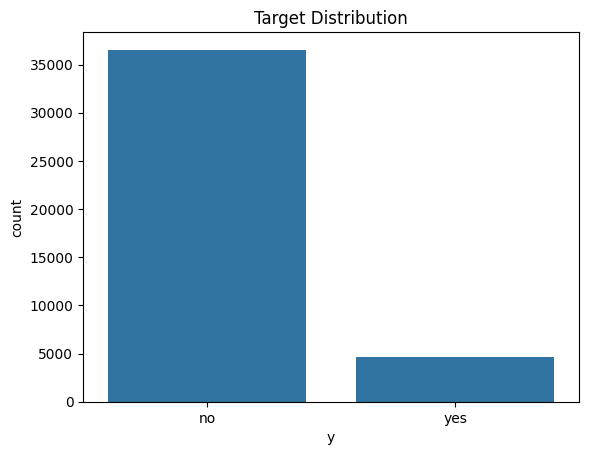

,proportion
y,
no,0.887346
yes,0.112654


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="y", data=df)
plt.title("Target Distribution")
plt.show()

df["y"].value_counts(normalize=True)

**STEP 4 — Data Cleaning**

Remove duplicates to avoid bias.

Handle missing values: numeric → median, categorical → “missing”.

Protect the target variable (y) from corruption.

Convert target to numeric (0/1 for classification).

In [8]:
import numpy as np

# Remove duplicate rows
df = df.drop_duplicates()

# Separate target FIRST
y = df["y"].copy()
X = df.drop("y", axis=1)

# Replace "unknown" ONLY in features
cat_cols = X.select_dtypes(include=["object"]).columns
X[cat_cols] = X[cat_cols].replace("unknown", np.nan)

# Handle missing values
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("missing")

# Now safely map target
y = y.str.strip()
y = y.map({"yes": 1, "no": 0})
y = y.astype(int)

# Combine back
df = pd.concat([X, y], axis=1)

print(df["y"].value_counts())


y
0    36537
1     4639
Name: count, dtype: int64


**Train-Test Split (before encoding/scaling)**

Split dataset into training (used to fit the model) and testing (simulate unseen data).

Stratification preserves class distribution in both sets.

Test set is not balanced artificially to simulate real-world deployment.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (32940, 20)
Test size: (8236, 20)


**STEP 6 — Encoding & Scaling**

Machine learning models require numerical input.

Categorical encoding → OneHotEncoder (binary columns for categories).

Numeric scaling → StandardScaler (mean=0, std=1) helps models like Logistic Regression, PCA, or distance-based models.

Done after splitting to prevent leakage.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# Fit on train, transform train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


**STEP 7 - Feature Selection (SelectKBest with Chi-Square)**

Reduce dimensionality to important features only.

Improves model performance and interpretability.

Used SelectKBest with Chi-Square for categorical/numerical features.

In [11]:
from sklearn.feature_selection import SelectKBest, chi2

# Chi-Square expects non-negative values → take absolute
selector = SelectKBest(score_func=chi2, k=15)
X_train_selected = selector.fit_transform(abs(X_train_processed), y_train)
X_test_selected = selector.transform(abs(X_test_processed))

# Optional: get selected feature names
feature_names = preprocessor.get_feature_names_out()
selected_feature_names = feature_names[selector.get_support()]
print("Selected features:", selected_feature_names)

Selected features: ['num__age' 'num__duration' 'num__pdays' 'num__previous'
 'num__emp.var.rate' 'num__euribor3m' 'num__nr.employed'
 'cat__job_retired' 'cat__job_student' 'cat__contact_telephone'
 'cat__month_mar' 'cat__month_may' 'cat__month_oct' 'cat__month_sep'
 'cat__poutcome_success']


**STEP 8 - Dimensionality Reduction (PCA)**

PCA reduces feature space while retaining variance.

Helps speed up training and visualizes patterns.

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)  # reduce to 10 components
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.38732639 0.15690209 0.12727012 0.0894116  0.08197797 0.07178788
 0.04163911 0.01615312 0.00871443 0.0053266 ]


**STEP 9 - Handle Class Imbalance (SMOTE)**

Minority class is underrepresented (~11% in this dataset).

Synthetic Minority Oversampling Technique (SMOTE) generates synthetic samples of the minority class.

Only applied on training set to avoid leaking information.

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_pca, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: y
0    29229
1     3711
Name: count, dtype: int64
After SMOTE: y
0    29229
1    29229
Name: count, dtype: int64


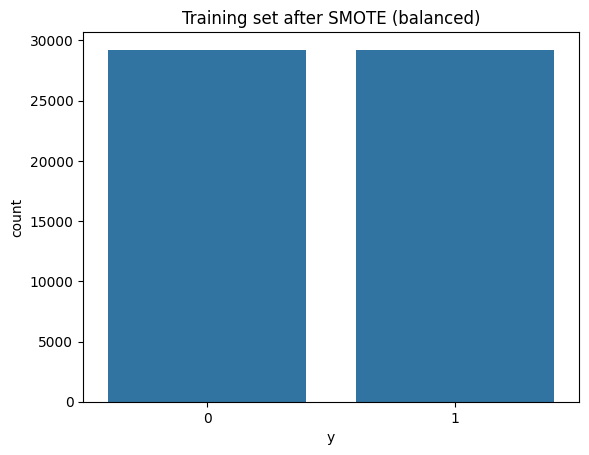

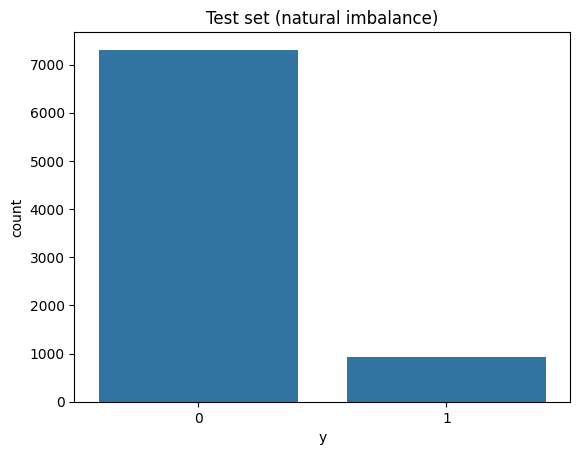

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train_sm)
plt.title("Training set after SMOTE (balanced)")
plt.show()

sns.countplot(x=y_test)
plt.title("Test set (natural imbalance)")
plt.show()

**STEP 10 — Model Building & Comparison**

Train multiple models to compare performance.

Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_sm, y_train_sm)

y_pred_log = log_model.predict(X_test_pca)
y_prob_log = log_model.predict_proba(X_test_pca)[:,1]

Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf = rf_model.predict(X_test_pca)
y_prob_rf = rf_model.predict_proba(X_test_pca)[:,1]

**STEP 11 — Evaluation**

Confusion matrix → TN, FP, FN, TP

Classification report → Precision, Recall, F1-score

ROC-AUC → probability-based performance

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      7308
           1       0.43      0.79      0.56       928

    accuracy                           0.86      8236
   macro avg       0.70      0.83      0.74      8236
weighted avg       0.91      0.86      0.88      8236

ROC-AUC: 0.8959262286959968

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7308
           1       0.47      0.67      0.56       928

    accuracy                           0.88      8236
   macro avg       0.71      0.79      0.74      8236
weighted avg       0.90      0.88      0.89      8236

ROC-AUC: 0.9017331473066832


Confusion Matrix

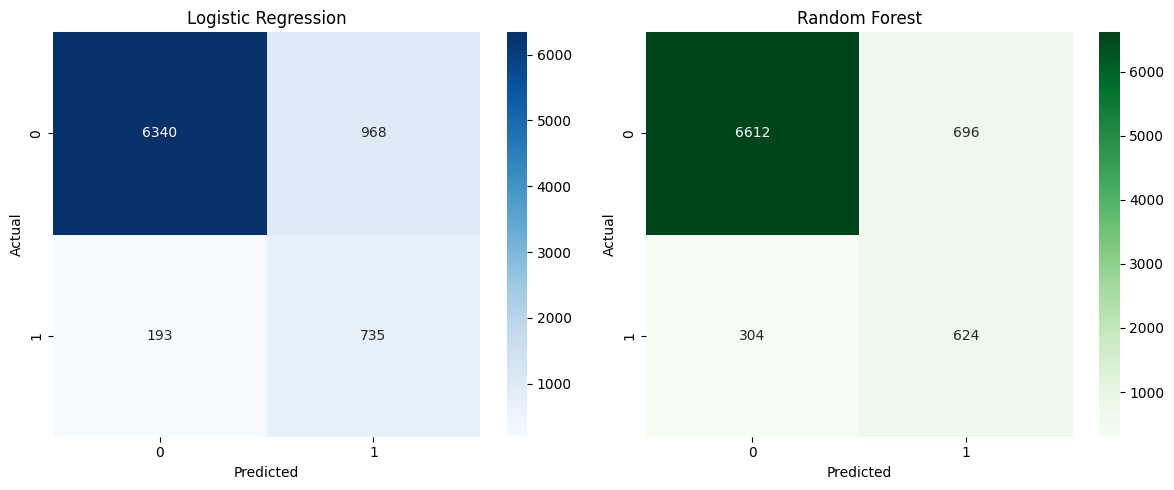

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1], yticklabels=[0,1], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Logistic Regression")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=[0,1], yticklabels=[0,1], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()